**Tutorial Code by Amirhossein Ahrari YouTube:** https://www.youtube.com/@amirhosseinahrarigee

**Tutorial Video: PySTAC Tutorial-9: Sentinel-2 NDVI Clustering and Crop Type Mapping using KMeans in Python**

This code is part of a tutorial series on python eo programming techniques
presented on the Amirhossein Ahrari YouTube channel. You are free to use and modify
this code for academic and non-academic purposes. Don't forget to subscribe to
the Amirhossein Ahrari channel and follow the videos to support the instructor.

In [1]:
!pip install -q pystac-client stackstac

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.0 MB/s eta 0:00:00


In [2]:
from pystac_client import Client

In [3]:
catalog = Client.open(
    'https://earth-search.aws.element84.com/v1'
)

In [4]:
for collection in catalog.get_collections():
  print(collection.id)

sentinel-2-pre-c1-l2a
cop-dem-glo-30
naip
cop-dem-glo-90
landsat-c2-l2
sentinel-2-l2a
sentinel-2-l1c
sentinel-2-c1-l2a
sentinel-1-grd


In [5]:
roi = [48.476923, 32.22186, 48.516906, 32.255415]

In [6]:
search = catalog.search(
    collections = ['sentinel-2-c1-l2a'],
    bbox = roi,
    datetime = '2022/2025'
)

In [7]:
items = search.item_collection()

/usr/local/lib/python3.13/dist-packages/pystac/extensions/storage.py:724: UserWarning: Could not parse bucket/account from href. The following assets were not migrated: ['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail']
  warnings.warn(


In [8]:
len(items)

239

In [12]:
items[0].properties['proj:code']

'EPSG:32639'

In [15]:
items[0].assets.keys()

dict_keys(['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail'])

In [16]:
import stackstac

In [17]:
ds_stack = stackstac.stack(
    items,
    assets = ['red','nir','scl'],
    bounds_latlon = roi,
    epsg =  32639,
    resolution = 10
)

In [19]:
ds = (
    ds_stack.to_dataset('band')
    .drop_dims('band')
    .reset_coords(drop = True)
    .drop_attrs()
)

In [20]:
ds

<xarray.Dataset> Size: 846MB
Dimensions:  (time: 239, y: 382, x: 386)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2022-03-21T07:40:55.976000 ... 2025-12...
  * y        (y) float64 3kB 3.572e+06 3.572e+06 ... 3.568e+06 3.568e+06
  * x        (x) float64 3kB 2.622e+05 2.622e+05 ... 2.661e+05 2.661e+05
Data variables:
    red      (time, y, x) float64 282MB dask.array<chunksize=(1, 382, 386), meta=np.ndarray>
    nir      (time, y, x) float64 282MB dask.array<chunksize=(1, 382, 386), meta=np.ndarray>
    scl      (time, y, x) float64 282MB dask.array<chunksize=(1, 382, 386), meta=np.ndarray>

In [21]:
mask = ds.scl.isin([3,8,9,10]).astype(int)
# 1 is cloud and 0 means clear
ds_mask = ds[['nir','red']].where(mask == 0)

In [22]:
red = ds_mask['red']
nir = ds_mask['nir']
ndvi = (nir - red) / (nir + red)

In [23]:
ndvi_weekly = ndvi.resample(time = 'W').max('time')

In [24]:
from dask.diagnostics import ProgressBar

In [26]:
import warnings
warnings.filterwarnings('ignore', category = RuntimeWarning)
import logging
logging.getLogger().setLevel(logging.ERROR)

In [27]:
with ProgressBar():
  ndvi_weekly = ndvi_weekly.compute()

[########################################] | 100% Completed | 167.40 s


In [29]:
ndvi_smoothing = ndvi_weekly.rolling(
    time = 5,
    center = True,
    min_periods = 1
).mean('time')

In [32]:
ndvi_interp = ndvi_smoothing.interpolate_na(dim = 'time', method = 'linear')
ndvi_interp = ndvi_interp.ffill(dim = 'time').bfill(dim = 'time')

In [36]:
from sklearn.cluster import KMeans

In [37]:
import numpy as np

In [41]:
ndvi_stack = ndvi_interp.stack(pixel = ['y','x']).transpose('pixel','time')

In [46]:
ndvi_arr = ndvi_stack.to_numpy()

In [47]:
ndvi_arr.shape

(147452, 198)

In [48]:
valid = np.isfinite(ndvi_arr).all(axis = 1)

In [50]:
model = KMeans(
    n_clusters = 4,
    random_state = 42,
    n_init = 10
)

In [51]:
label = model.fit_predict(ndvi_arr[valid])

In [53]:
all_labels = np.full(ndvi_stack.sizes['pixel'], np.nan)
all_labels[valid] = label

In [55]:
import xarray as xr

In [56]:
xr_label = xr.DataArray(
    all_labels,
    dims = ['pixel'],
    coords = {'pixel': ndvi_stack.pixel}
).unstack('pixel').transpose('y','x')

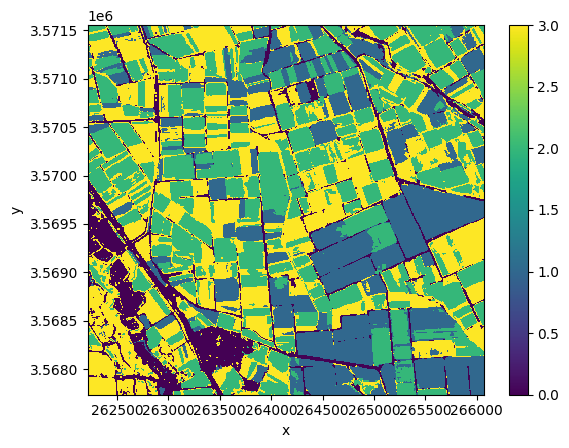

In [58]:
xr_label.plot(robust = True)

In [59]:
!pip -q install rioxarray
import rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.2 MB/s eta 0:00:00


In [60]:
out = xr_label.copy()
out = out.rio.write_crs('EPSG:32639')
out = out.rio.set_spatial_dims(x_dim = 'x', y_dim = 'y')
out = out.rio.write_coordinate_system(inplace = True)
out = out.transpose('y','x')

In [62]:
out.rio.to_raster('crop_type.tiff')